In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
from scipy.optimize import fsolve   

from tqdm import tqdm
import arviz

d:\anaconda3\envs\holenv\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


## Question 2

In [2]:
def normal_pdf(x, mu, sigma):
    return norm.pdf(x, loc=mu, scale=sigma)

# Prior definition
prior_mu = 20
prior_sigma = 2

In [3]:
# Likelihood
first_measurements = [19.08, 19.88]
second_measurements = [
    20.63, 20.33, 20.11, 19.79, 18.25, 19.58, 19.71, 21.25, 19.75, 20.34
]
mu_1 = np.mean(first_measurements)
mu_2 = np.mean(second_measurements)
sigma_1 = 0.5
sigma_2 = 1


$\mu_{post} = \frac{\sigma^2 \mu + n \tau^2 \bar{x}}{\sigma^2 + n \tau^2}$ , $\tau^2_{post} = \frac{\sigma^2 \tau^2}{\sigma^2 + n \tau^2}$

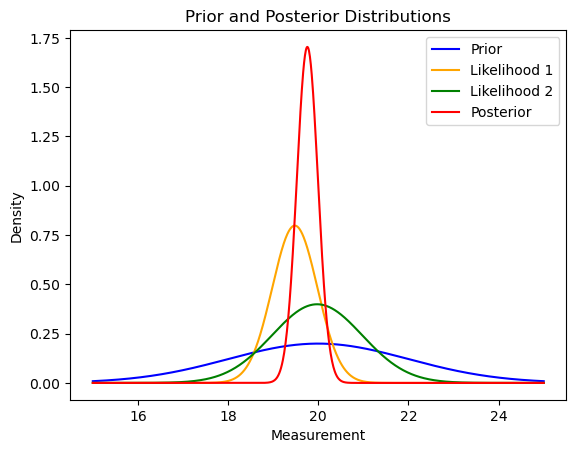

Posterior mean: 19.758
Posterior variance: 0.055


In [16]:
def normal_posterior_mean_update(prior_mu, prior_sigma, likelihood_mus: list, likelihood_sigmas: list, likelihood_ns: list = None):
    precision_prior = 1 / prior_sigma**2
    if likelihood_ns is not None:
        precision_likelihoods = [n / sigma**2 for n, sigma in zip(likelihood_ns, likelihood_sigmas)]
    else:
        precision_likelihoods = [1 / sigma**2 for sigma in likelihood_sigmas]
    
    combined_precision = precision_prior + sum(precision_likelihoods)
    
    weighted_sum = precision_prior * prior_mu + sum(precision * mu for precision, mu in zip(precision_likelihoods, likelihood_mus))
    
    posterior_mu = weighted_sum / combined_precision
    posterior_sigma = np.sqrt(1 / combined_precision)
    return posterior_mu, posterior_sigma

posterior_mu, posterior_sigma = normal_posterior_mean_update(prior_mu, prior_sigma, [mu_1, mu_2], [sigma_1, sigma_2], [len(first_measurements), len(second_measurements)])

x = np.linspace(15, 25, 1000)
plt.plot(x, normal_pdf(x, prior_mu, prior_sigma), label='Prior', color='blue')
plt.plot(x, normal_pdf(x, mu_1, sigma_1), label='Likelihood 1', color='orange')
plt.plot(x, normal_pdf(x, mu_2, sigma_2), label='Likelihood 2', color='green')
plt.plot(x, normal_pdf(x, posterior_mu, posterior_sigma), label='Posterior', color='red')
plt.title('Prior and Posterior Distributions')
plt.xlabel('Measurement')
plt.ylabel('Density')
plt.legend()
plt.show()
print(f"Posterior mean: {posterior_mu:.3f}")
print(f"Posterior variance: {posterior_sigma**2:.3f}")

In [17]:
# Find 95% credible interval for the posterior distribution
lower_bound = norm.ppf(0.025, loc=posterior_mu, scale=posterior_sigma)
upper_bound = norm.ppf(0.975, loc=posterior_mu, scale=posterior_sigma)
print(f"95% credible interval for the posterior mean: [{lower_bound:.3f}, {upper_bound:.3f}]")


95% credible interval for the posterior mean: [19.299, 20.217]
